## create local automata

In [182]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
import copy

def creare_random_connected_graph(n_nodes, n_edges):
    # Generate a random graph
    G = nx.Graph()

    # Add nodes
    G.add_nodes_from(range(n_nodes))

    # Add random edges
    while G.number_of_edges() < n_edges:
        u = random.randint(0, n_nodes-1)
        v = random.randint(0, n_nodes-1)
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)
    # Check if graph is connected
    while not nx.is_connected(G):
        # Add random edges until connected
        # get disconnected node
        disconnected_node = random.choice(list(nx.isolates(G)))
        # get random node
        random_node = random.choice(list(G.nodes()))
        if disconnected_node != random_node and not G.has_edge(disconnected_node, random_node):
            G.add_edge(disconnected_node, random_node)
    return G


colors = [np.random.rand(3,) for _ in range(5)]
graphs = []
pos_list = []
graphs_number = 5
nodes_number = 5
edges_number = 7

for _ in range(graphs_number):
    G = creare_random_connected_graph(nodes_number, edges_number)
    graphs.append(G)
    pos_list.append(nx.spring_layout(G))

In [145]:
def generate_random_conditions(graph, graphs_number, target_automaton, max_edge_conditions):
    nodes_number = len(graph.nodes())
    conditions = {}

    for edge in graph.edges(data=True):
        edge_conditions_number = random.randint(0, max_edge_conditions)
        conditions[(edge[0], edge[1])] = []

        available_automatons = [x for x in range(graphs_number) if x != target_automaton]

        for n in range(edge_conditions_number):
            automaton_index = random.randint(0, len(available_automatons)-1)
            condition = {"automaton": available_automatons[automaton_index], 
                        "state": random.randint(0, nodes_number),
                        "color": colors[available_automatons[automaton_index]],
                        "fontsize": 12,
                        "solved": False,
                        "being_solved": False,}
            available_automatons.remove(available_automatons[automaton_index])

            conditions[(edge[0], edge[1])].append(condition)

    return conditions

## prepare states

In [187]:
numbers = np.random.randint(0, nodes_number, size=nodes_number)
target_automaton = 0
target_state = 0
max_conditions_per_edge = 3
highlighted_states = {}

steps = []
shortest_paths = {}
shortest_paths_visualize = {}

current_edges = {}
current_edges_visualize = {}

conditions = {}
edge_conditions_visualize = {}

for i in range(graphs_number):
    target_automaton = i % graphs_number
    target_state = i % graphs_number
    highlighted_nodes = []

    highlighted_nodes.append({'state': numbers[i], 'color': colors[i], 'node_size': 600, 'edge_color': 'black', 'linewidth': 4})
    if i == 0:
        highlighted_nodes.append({'state': 0, 'color': 'red', 'node_size': 600, 'edge_color': None, 'linewidth':4})
        
    if graphs[i].has_edge(numbers[i], target_state):
        current_edge = (numbers[i], target_state)
    else:
        current_edge = None

    shortest_path = nx.shortest_path(graphs[i], source=numbers[i], target=target_state)
    graph_conditions = generate_random_conditions(graphs[i], graphs_number, target_automaton, max_conditions_per_edge)

    highlighted_states[target_automaton] = highlighted_nodes
    shortest_paths[target_automaton] = {'path': shortest_path, 'color': 'blue', 'width': 3} if shortest_path != None else None
    shortest_paths_visualize[target_automaton] = True

    conditions[target_automaton] = graph_conditions
    edge_conditions_visualize[target_automaton] = True
    current_edges[target_automaton] = {'edge': current_edge, 'color': 'red', 'width': 10} if current_edge != None else None
    current_edges_visualize[target_automaton] = True

for i in range(graphs_number):
    target_automaton = i % graphs_number
    target_state = i % graphs_number

    current_edges_visualize_temp = {}
    shortest_paths_visualize_temp = {}
    highlighted_states_temp = {}

    for value in current_edges_visualize:
        if value != target_automaton:
            current_edges_visualize_temp[value] = False
            shortest_paths_visualize_temp[value] = False
            highlighted_states_temp[value] = None
        else:
            current_edges_visualize_temp[value] = True
            shortest_paths_visualize_temp[value] = True
            highlighted_states_temp[value] = highlighted_states[value]

    steps.append({
                'goal': {
                    'target_automaton': target_automaton,
                    'target_state': target_state
                },
                'local_states': copy.deepcopy(numbers),
                'shortest_paths': copy.deepcopy(shortest_paths),
                'edge_conditions': copy.deepcopy(conditions),
                'current_edges': copy.deepcopy(current_edges),
                'visualize': {
                    'current_edges_visualize': copy.deepcopy(current_edges_visualize_temp),
                    'highlighted_states': copy.deepcopy(highlighted_states_temp),
                    'shortest_paths_visualize': copy.deepcopy(shortest_paths_visualize_temp),
                    'edge_conditions_visualize': copy.deepcopy(edge_conditions_visualize),
                }
    })

print(steps)
print(len(steps))
print(shortest_paths)

[{'goal': {'target_automaton': 0, 'target_state': 0}, 'local_states': array([4, 4, 3, 3, 3]), 'shortest_paths': {0: {'path': [4, 0], 'color': 'blue', 'width': 3}, 1: {'path': [4, 1], 'color': 'blue', 'width': 3}, 2: {'path': [3, 2], 'color': 'blue', 'width': 3}, 3: {'path': [3], 'color': 'blue', 'width': 3}, 4: {'path': [3, 4], 'color': 'blue', 'width': 3}}, 'edge_conditions': {0: {(0, 3): [{'automaton': 1, 'state': 4, 'color': array([0.47652424, 0.9185685 , 0.57704227]), 'fontsize': 12, 'solved': False, 'being_solved': False}, {'automaton': 3, 'state': 0, 'color': array([0.31820227, 0.75653982, 0.11014772]), 'fontsize': 12, 'solved': False, 'being_solved': False}, {'automaton': 2, 'state': 3, 'color': array([0.25455704, 0.51216032, 0.15336655]), 'fontsize': 12, 'solved': False, 'being_solved': False}], (0, 4): [{'automaton': 2, 'state': 3, 'color': array([0.25455704, 0.51216032, 0.15336655]), 'fontsize': 12, 'solved': False, 'being_solved': False}, {'automaton': 1, 'state': 3, 'color'

In [188]:
for i, item in enumerate(steps):
    print(item['goal']['target_state'], numbers[i])

0 4
1 4
2 3
3 3
4 3


In [198]:
# manually change edge conditions
steps[0]['edge_conditions'][0][(0, 4)][0]['being_solved'] = True
steps[1]['edge_conditions'][1][(1, 4)][0]['solved'] = True
for i in range(1,len(steps)):
    steps[i]['edge_conditions'][0][(0, 4)][0]['being_solved'] = True
for i in range(2,len(steps)):
    steps[i]['edge_conditions'][1][(1, 4)][0]['solved'] = True

## Visualizer functions

In [185]:
SOLVED_COLOR = 'grey'
SOLVED_FONTSIZE = 8
SOLVING_FONTSIZE = 42


def visualize_current_edge(step, automaton_idx, graph, pos, ax):
        
        current_edge = step['current_edges'][automaton_idx]

        if step['visualize']['current_edges_visualize'][automaton_idx] == True and current_edge != None:
            color = current_edge['color']
            width = current_edge['width']
            
            nx.draw_networkx_edges(graph, pos, ax=ax,
                                    edgelist=[(current_edge['edge'][0], current_edge['edge'][1])],
                                    edge_color=color,
                                    width=width)
            
def highlight_state(step, automaton_idx, graph, pos, ax):
    hightlighted_nodes = step['visualize']['highlighted_states'][automaton_idx]

    if hightlighted_nodes != None:

        for item in hightlighted_nodes:
            color = item['color']
            node_size = item['node_size']
            edge_color = item['edge_color']
            linewidth =  item['linewidth']
            nx.draw_networkx_nodes(G, pos, ax=ax,
                                nodelist=[item['state']],
                                node_color=color,
                                edgecolors=edge_color,
                                node_size=node_size,
                                linewidths=linewidth)
    
def highlight_shortest_path(step, automaton_idx, graph, pos, ax):
    if step['visualize']['shortest_paths_visualize'][automaton_idx] and step['shortest_paths'][automaton_idx] != None:
        shortest_path = step['shortest_paths'][automaton_idx]['path']

        for i in range(len(shortest_path)-1):
            nx.draw_networkx_edges(graph, pos, ax=ax,
                                edgelist=[(shortest_path[i], shortest_path[i+1])],
                                edge_color='blue',
                                width=3)
            
def visualize_edge_conditions(step, automaton_idx, graph, pos, ax):
     if step['visualize']['edge_conditions_visualize'][automaton_idx] and step['edge_conditions'][automaton_idx] != None:
        for edge in graph.edges(data=True):
                for m, condition in enumerate(step["edge_conditions"][automaton_idx][(edge[0], edge[1])]):
                    edge_pos = pos[edge[0]] + (pos[edge[1]] - pos[edge[0]]) * 0.5
                    
                    if condition['solved'] == True:
                        plt.text(edge_pos[0]+0.05*m, edge_pos[1]+0.05, f'{condition["state"]}', color=SOLVED_COLOR, fontsize=SOLVED_FONTSIZE)
                    elif condition['being_solved'] == True:
                        plt.text(edge_pos[0]+0.05*m, edge_pos[1]+0.05, f'{condition["state"]}', color=condition['color'], fontsize=SOLVING_FONTSIZE)
                    else:
                        plt.text(edge_pos[0]+0.05*m, edge_pos[1]+0.05, f'{condition["state"]}', color=condition['color'], fontsize=condition['fontsize'])

visualize_dict = {
    'shortest_paths_visualize': lambda step, automaton_idx, graph, pos, ax: highlight_shortest_path(step, automaton_idx, graph, pos, ax),
    'current_edges_visualize': lambda step, automaton_idx, graph, pos, ax: visualize_current_edge(step, automaton_idx, graph, pos, ax),
    'highlighted_states': lambda step, automaton_idx, graph, pos, ax: highlight_state(step, automaton_idx, graph, pos, ax),
    'edge_conditions_visualize': lambda step, automaton_idx, graph, pos, ax: visualize_edge_conditions(step, automaton_idx, graph, pos, ax)
}

## animate

/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


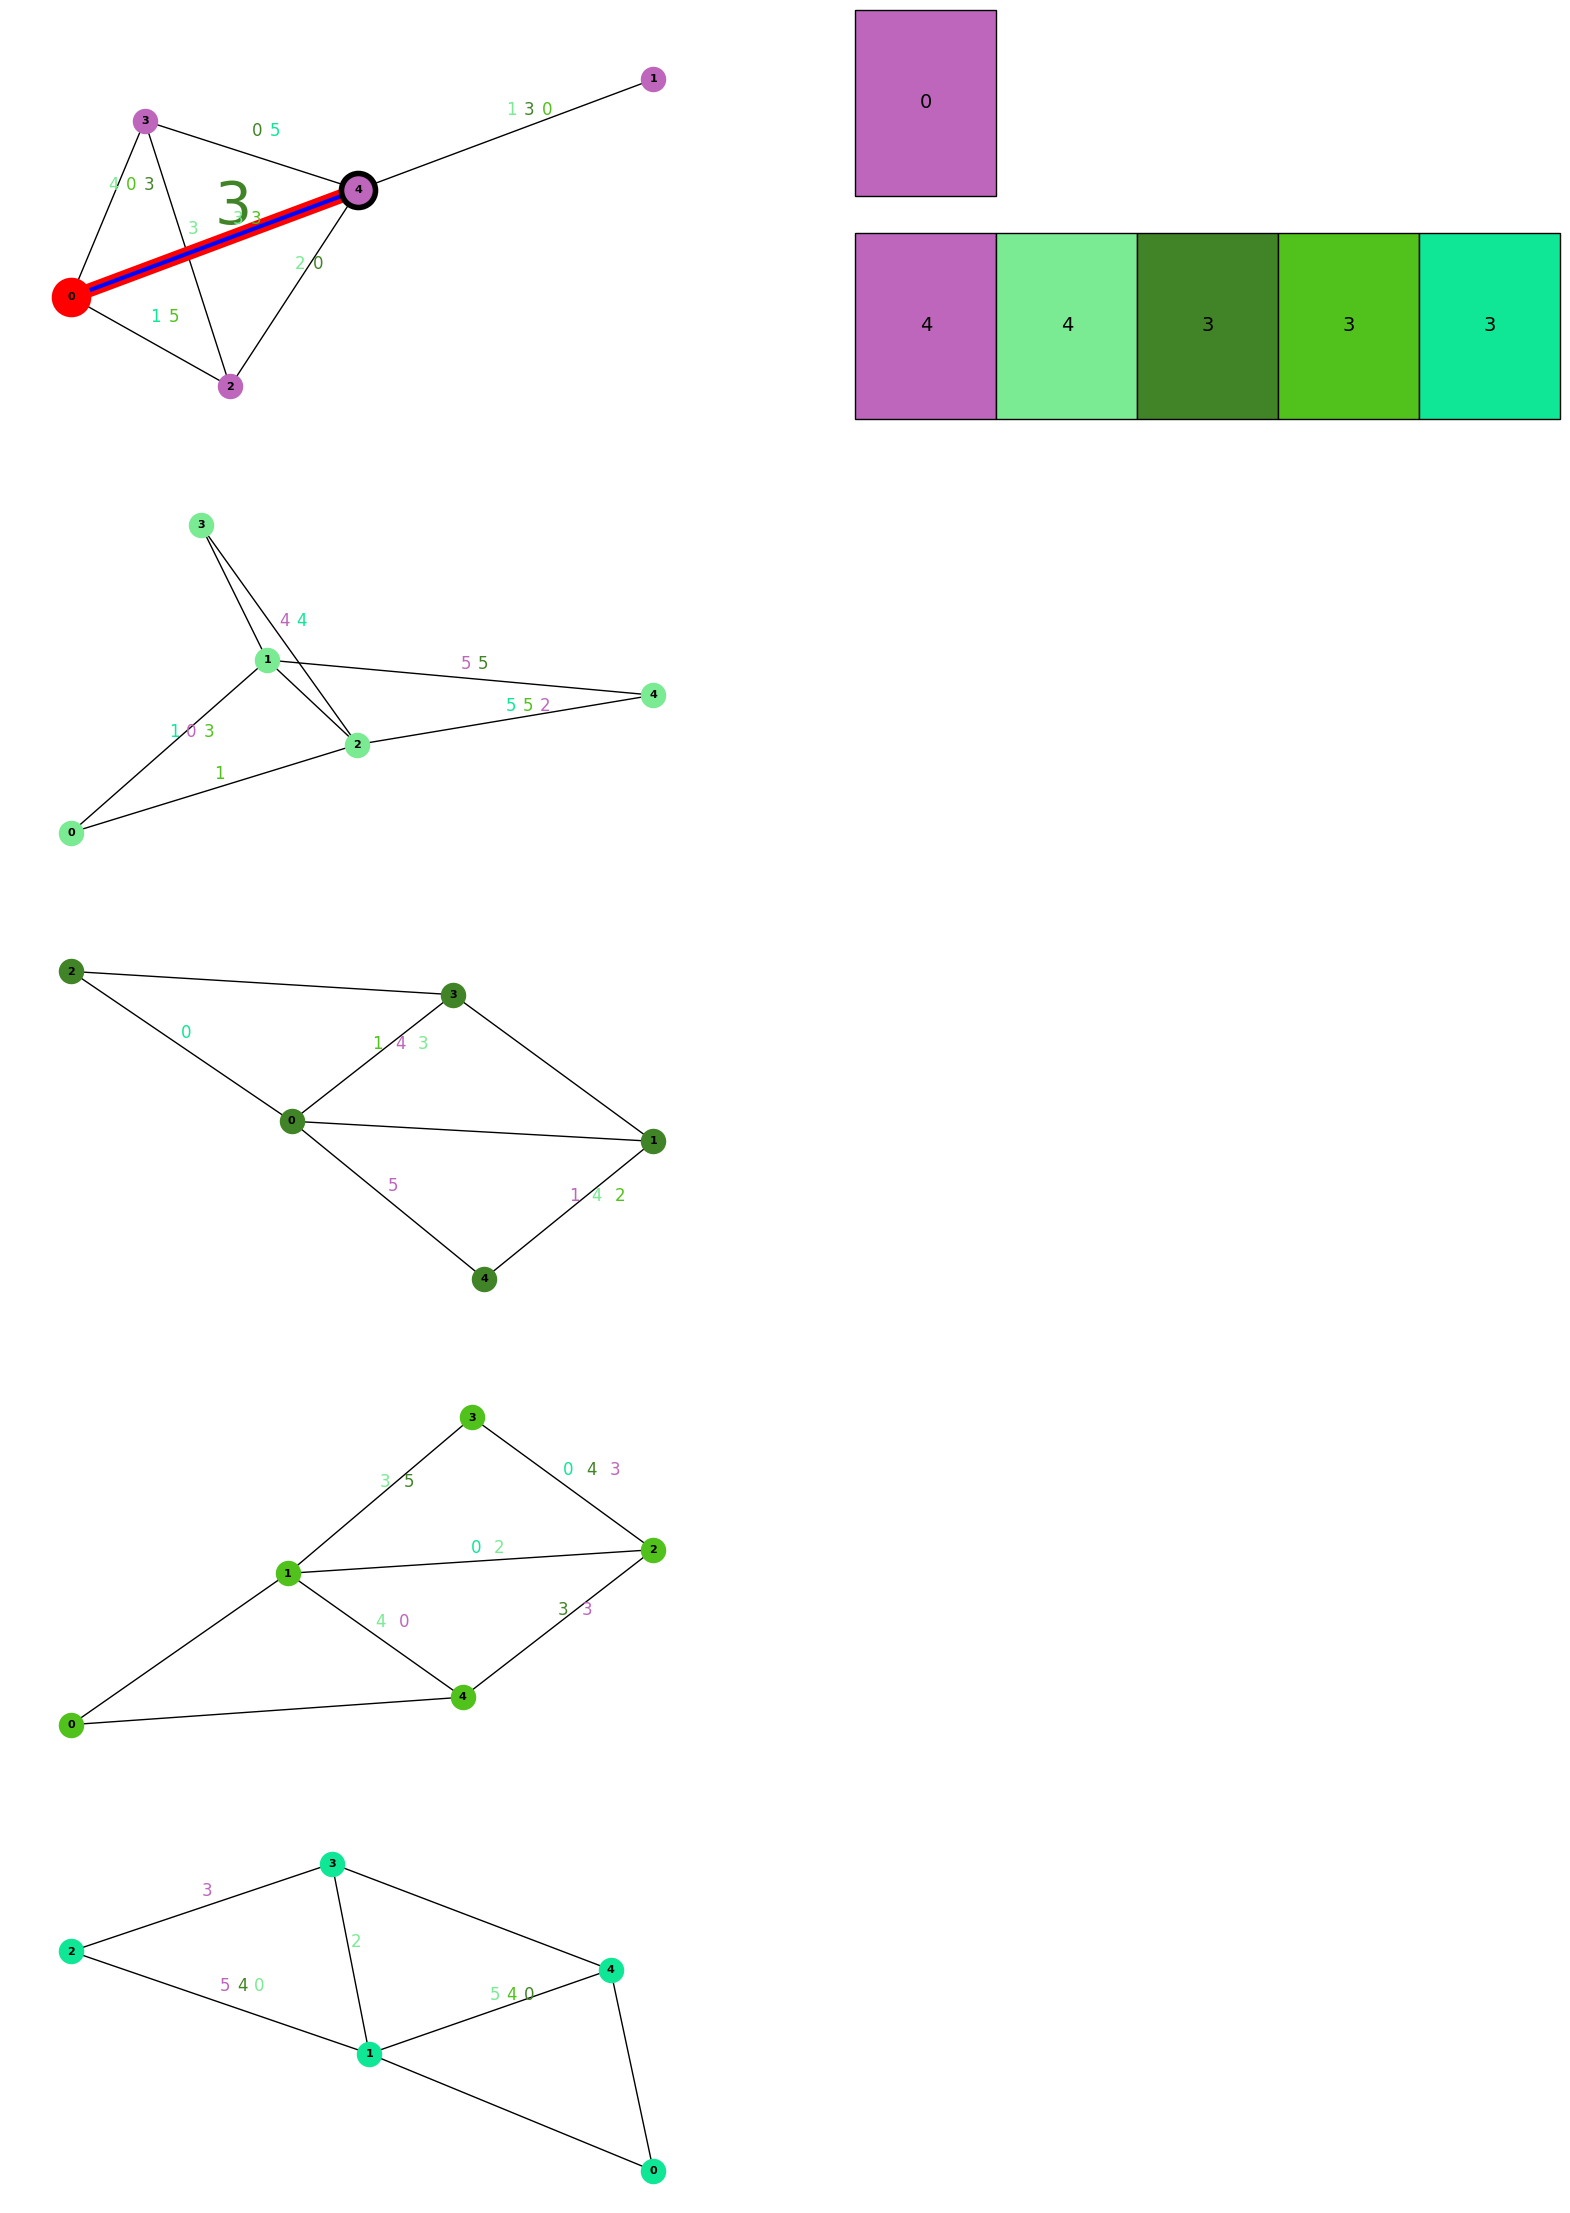

In [199]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with custom gridspec
fig = plt.figure(figsize=(20, 28))
gs = plt.GridSpec(graphs_number, 2, figure=fig)

# Function to update the frame
def update(frame, steps):
    current_step = steps[frame]
    current_goal = current_step['goal']
    target_state = current_goal['target_state']
    target_automaton = current_goal['target_automaton']

    numbers = current_step['local_states']

    # Clear the figure
    fig.clear()

    # Create 5 random graphs in the first column
    for i in range(graphs_number):
        local_state = numbers[i]
        
        ax = fig.add_subplot(gs[i, 0])
        # Generate random graph
        G = graphs[i]
        
        # Draw the graph
        pos = pos_list[i]
        
        # Draw all nodes
        nx.draw(G, pos, ax=ax, with_labels=True,
                node_color=colors[i], node_size=300,
                font_size=8, font_weight='bold')
        
        for item in current_step['visualize']:
            visualize_dict[item](current_step, i, G, pos, ax)

        #ax.set_title(f'Random Graph {i+1}')

    # Create 1 subplot spanning all rows in second column
    ax = fig.add_subplot(gs[:1, 1])

    ax.clear()
    ax.axis('off')
    # Create vector of 5 random numbers
    top_row = [str(target_state)]
    top_colors = [colors[target_automaton]]
    # Create sample data for tables
    table1 = ax.table(cellText=[numbers],
                    cellColours=[colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0, 0, 1, 0.5])

    table2 = ax.table(cellText=[top_row],
                    cellColours=[top_colors],
                    cellLoc='center',
                    loc='center',
                    bbox=[0.2*target_automaton, 0.6, 0.2, 0.5]) # prvni souradnice ovlivnuje umisteni vrchni bunky

    # Style the tables
    table1.set_fontsize(14)
    table2.set_fontsize(14)

# Create animation
anim = animation.FuncAnimation(fig, update, frames=5,
                               fargs=(steps,) ,
                             interval=1000, repeat=True)
anim.save('search_animation.gif', writer='pillow')



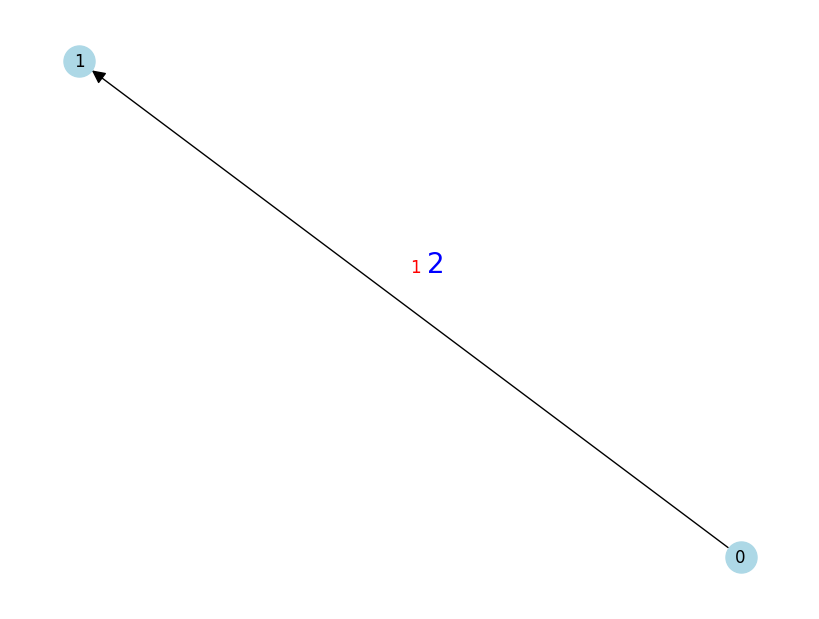

In [197]:
# Create a new figure
plt.figure(figsize=(8,6))

# Create a directed graph
G = nx.DiGraph()
G.add_edge(0, 1)

# Set up the layout
pos = nx.spring_layout(G)

# Draw the graph
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=500, arrowsize=20)

# Create edge labels with different colors
edge_labels = {(0,1): ''}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Add the colored numbers separately
# Get the edge midpoint position
edge_pos = pos[0] + (pos[1] - pos[0]) * 0.5
plt.text(edge_pos[0], edge_pos[1]+0.05, '1', color='red', fontsize=12)
plt.text(edge_pos[0]+0.05, edge_pos[1]+0.05, '2', color='blue', fontsize=20)

plt.axis('off')
plt.show()
